# Imagination Machines III
## Universal Spectral Representation via Cyclic Lifting
### Ensemble Variant: Mean-Pooled Parameter Vector

This notebook implements the **ensemble variant** of the Imagination Machines III cyclic lifting experiment.
For each of N environments, M differently-initialized agents are trained on the same
observation trajectory. After training, the M full converged parameter vectors are
mean-pooled to produce a single vector per environment. 

**Initialization seeds:** init m uses `SEED_WEIGHTS + m` (m = 0, ..., N_INITS-1),
identical across all environments. Any difference in the pooled parameter vector is
therefore attributable solely to the dynamical structure of the environment.

**Notebook structure:**
- Cell 1 — Pytorch installation
- Cell 2 — Imports, configuration, master seed (adds `N_INITS`)
- Cell 3 — Cyclic lifting and observation model (unchanged)
- Cell 4 — Agent architecture
- Cell 5 — vmap infrastructure
- Cell 6 — Learning rate search (unchanged)
- Cell 7 — Ensemble training loop: N_ENVS × N_INITS agents, mean-pool full parameter vectors
- Cell 8 — Save / load dataset
- Cell 9 — Environment sanity check
- Cell 10 — Linear probe: P random slices, k-fold CV
- Cell 11 — Visualization

Global note: numerical dimensions mentioned in comments are illustrative only; actual values may vary

In [1]:
# ============================================================
# Cell 1 | Installation (SCC)
# ============================================================
#
# Installs PyTorch to the project directory to avoid home
# directory quota limits. Run once, then restart the kernel.
# After restart, the sys.path insertion will need to be
# re-run before importing torch.
# ============================================================

import sys
import os

INSTALL_DIR = ""

# Install torch to project directory
os.makedirs(INSTALL_DIR, exist_ok=True)
!{sys.executable} -m pip install torch --target={INSTALL_DIR}

# Add to path
if INSTALL_DIR not in sys.path:
    sys.path.insert(0, INSTALL_DIR)

# Verify
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"GPU count       : {torch.cuda.device_count()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 143.3 MB/s  0:00:03.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 207.8 MB/s  0:00:01.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 234.1 MB/s  0:00:00.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 215.9 MB/s  0:00:00.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 211.0 MB/s  0:00:004.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 161.6 MB/s  0:00:01 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 203.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 217.5 MB/s  0:00:01.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 239.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 207.9 MB/s  0:00:00206.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 M

In [2]:
# ============================================================
# Cell 2 (TIM X) | Imports, Configuration, Master Seed
# ============================================================

import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, List

# --- Reproducibility ---
MASTER_SEED   = 76
SEED_ENV      = MASTER_SEED + 1
SEED_WEIGHTS  = MASTER_SEED + 2   # base seed; init m uses SEED_WEIGHTS + m
SEED_TRAINING = MASTER_SEED + 3

# --- Sequence source ---
SEQUENCE_SOURCE = "unit_fractions"  # "unit_fractions" | "pi"
M_CYCLIC        = 10                # cyclic group order (decimal digits)
N_PI_DIGITS     = 100_000           # digits of pi to pre-generate
FRACTION_NS     = [7, 11, 13, 17,   # denominators for 1/n pool
                   19, 23, 29, 31,
                   37, 41, 43, 47]

# --- Agent ---
OBS_DIM        = 6
STATE_DIM      = 32
MLP_HIDDEN_DIM = 32                 # compressive bottleneck: d_h < d_s + d_o

# --- Training ---
N_ENVS            = 5000
N_INITS           = 1               # M: distinct initializations per environment
T_STEPS           = 200
N_EPOCHS_PER_ENV  = 100
LEARNING_RATE     = 1e-2
VMAP_CHUNK_SIZE   = 200
CONTEXT_NORMALIZE = False           # False | "full" | "rolling"

# --- Probe ---
PROBE_K_FOLDS = 5
N_PROBE_MODES = 3                   # number of independent Koopman modes to probe

# --- I/O ---
LOAD_FROM_DISK = False
SAVE_DIR_ROOT  = ""

# --- Devices ---
DEVICE  = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DEVICES = [torch.device(f"cuda:{i}")
           for i in range(torch.cuda.device_count())] or [DEVICE]

torch.manual_seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

print(f"Sequence source  : {SEQUENCE_SOURCE}")
print(f"Fractions        : {[f'1/{n}' for n in FRACTION_NS]}")
print(f"Cyclic group     : Z/{M_CYCLIC}Z")
print(f"Environments     : {N_ENVS}")
print(f"Inits/env (M)    : {N_INITS}")
print(f"T_STEPS          : {T_STEPS}")
print(f"Epochs/env       : {N_EPOCHS_PER_ENV}")
print(f"OBS_DIM          : {OBS_DIM}")
print(f"STATE_DIM        : {STATE_DIM}")
print(f"MLP_HIDDEN_DIM   : {MLP_HIDDEN_DIM}  (bottleneck: {MLP_HIDDEN_DIM} < {STATE_DIM})")
print(f"N_PROBE_MODES    : {N_PROBE_MODES}")
print(f"Devices          : {DEVICES}")


Sequence source  : pi
Fractions        : ['1/7', '1/11', '1/13', '1/17', '1/19', '1/23', '1/29', '1/31', '1/37', '1/41', '1/43', '1/47']
Cyclic group     : Z/10Z
Environments     : 5000
Inits/env (M)    : 1
T_STEPS          : 200
Epochs/env       : 100
OBS_DIM          : 6
STATE_DIM        : 32
MLP_HIDDEN_DIM   : 32  (bottleneck: 32 < 32)
N_PROBE_MODES    : 3
Devices          : [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


In [3]:
# ============================================================
# Cell 3 (TIM X) | Cyclic Lifting and Observation Model
# ============================================================
#
# Implements the canonical character lifting for sequences
# over Z/M Z and the relational observation model.
#
# The environment pool consists of N fractions 1/n for
# distinct values of n drawn from FRACTION_NS. Each fraction
# has a decimal expansion with a known period p. The
# Koopman eigenvalues of the lifted sequence are the p-th
# roots of unity e^{2πik/p} for k=1,...,floor(p/2), which
# vary across environments — directly analogous to the
# rotation rates ω in TIM V.
#
# Observation model: for three consecutive digits
# (x_t, x_{t+1}, x_{t+2}), pairwise modular differences are
# computed in Z/MZ and lifted to the unit circle:
#
#   θ(d_ij) = 2π · ((x_i - x_j) mod M) / M  (mod 2π)
#
# Two sequence sources are supported via SEQUENCE_SOURCE:
#
#   "unit_fractions" — pool of 1/n expansions, positive
#                      experiment. Each environment is one
#                      fraction with its own Koopman spectrum.
#
#   "pi"             — decimal expansion of π, null experiment.
#                      PAIRED TEST: same ns, periods, and probe
#                      targets as unit_fractions — only the
#                      digit sequence differs. R² ≈ 0 on π
#                      confirms the bottleneck encodes nothing
#                      that covaries with the targets when the
#                      sequence is spectrally flat.
#
# M = 10 for decimal digit sequences (digits in {0,...,9}).
# ============================================================

# --- Digit sequence generation ---

def digits_fraction(n: int, length: int) -> np.ndarray:
    """
    Return the decimal digits of 1/n (after decimal point)
    by long division, tiled to the requested length.

    Parameters
    ----------
    n      : int — denominator
    length : int — number of digits to return

    Returns
    -------
    digits : np.ndarray (length,) int, values in {0,...,9}
    """
    digits    = []
    remainder = 1
    for _ in range(length + 10):
        remainder *= 10
        digits.append(remainder // n)
        remainder  = remainder % n
    return np.array(digits[:length], dtype=np.int32)


def period_of_fraction(n: int) -> int:
    """
    Return the period of the decimal expansion of 1/n
    by detecting the first repeated remainder in long division.

    Parameters
    ----------
    n : int — denominator

    Returns
    -------
    p : int — period length
    """
    remainders = {}
    remainder  = 1
    pos        = 0
    while remainder != 0:
        if remainder in remainders:
            return pos - remainders[remainder]
        remainders[remainder] = pos
        remainder = (remainder * 10) % n
        pos += 1
    return pos


def digits_pi(n: int) -> np.ndarray:
    """
    Return the first n decimal digits of π (after decimal point).
    Requires mpmath.
    """
    try:
        import mpmath
        mpmath.mp.dps = n + 10
        pi_str = mpmath.nstr(mpmath.pi, n + 5, strip_zeros=False)
        pi_str = pi_str.replace('3.', '').replace('.', '')
        return np.array([int(c) for c in pi_str[:n]], dtype=np.int32)
    except ImportError:
        raise ImportError(
            "mpmath required for pi digits.\n"
            "Install: pip install mpmath --break-system-packages"
        )


# --- Observation model ---

def observe_cyclic(
    digits_window: np.ndarray,
    M:             int = 10,
) -> np.ndarray:
    """
    Compute the 6-dimensional relational observation from a digit window.

    For each consecutive triple (x_t, x_{t+1}, x_{t+2}), computes
    pairwise modular differences in Z/MZ and lifts each to the
    unit circle via the canonical character:

        θ(d_ij) = 2π · ((x_i - x_j) mod M) / M  (mod 2π)

    Parameters
    ----------
    digits_window : (T+3,) int array — raw digit values
    M             : int — cyclic group order

    Returns
    -------
    obs : (T+1, 6) float array
    """
    T_plus_1 = len(digits_window) - 2

    d12_raw = (digits_window[:T_plus_1]    - digits_window[1:T_plus_1+1]) % M
    d13_raw = (digits_window[:T_plus_1]    - digits_window[2:T_plus_1+2]) % M
    d23_raw = (digits_window[1:T_plus_1+1] - digits_window[2:T_plus_1+2]) % M

    d12 = (2.0 * np.pi * d12_raw / M) % (2.0 * np.pi)
    d13 = (2.0 * np.pi * d13_raw / M) % (2.0 * np.pi)
    d23 = (2.0 * np.pi * d23_raw / M) % (2.0 * np.pi)

    return np.stack([
        np.cos(d12), np.sin(d12),
        np.cos(d13), np.sin(d13),
        np.cos(d23), np.sin(d23),
    ], axis=1).astype(np.float32)


def make_trajectory_cyclic(
    digits: np.ndarray,
    offset: int,
    T:      int,
    M:      int = 10,
) -> np.ndarray:
    """
    Generate one observation trajectory for a cyclic sequence agent.

    Parameters
    ----------
    digits : (N_digits,) int array — full digit sequence
    offset : int — starting position in digit sequence
    T      : int — trajectory length
    M      : int — cyclic group order

    Returns
    -------
    obs : (T+1, 6) float array
    """
    window = digits[offset : offset + T + 3]
    return observe_cyclic(window, M)


# --- Environment pool generation ---

def sample_cyclic_environments(
    n_envs: int,
    T:      int,
    seed:   int,
    source: str = SEQUENCE_SOURCE,
    M:      int = M_CYCLIC,
) -> tuple:
    """
    Sample N cyclic-group environments.

    For "unit_fractions": cycles through FRACTION_NS, assigning
    each agent a fraction 1/n with its own period and Koopman
    spectrum.

    For "pi": PAIRED TEST — uses the same ns, periods, and
    offsets structure as unit_fractions, but substitutes the
    decimal digits of π for the digit sequence. Probe targets
    are identical to the unit_fractions case. R² ≈ 0 on π
    means the bottleneck encodes nothing that covaries with
    the targets when the sequence is spectrally flat.

    Returns
    -------
    digit_seqs : list of np.ndarray — digit sequence per agent
    offsets    : np.ndarray (N,)    — window offsets
    periods    : np.ndarray (N,)    — period of each environment
    ns         : np.ndarray (N,)    — denominator for each agent
    """
    rng = np.random.default_rng(seed)

    # Both sources share the same ns/periods/offsets structure
    ns      = np.array([FRACTION_NS[i % len(FRACTION_NS)]
                        for i in range(n_envs)], dtype=np.int32)
    periods = np.array([period_of_fraction(int(n)) for n in ns],
                       dtype=np.int32)
    offsets = np.array([i % int(periods[i]) for i in range(n_envs)],
                       dtype=np.int32)

    if source == "unit_fractions":
        digit_seqs = [
            digits_fraction(int(ns[k]), T + 3 + periods[k])
            for k in range(n_envs)
        ]

    elif source == "pi":
        # Paired test: π digits, same structure as unit_fractions
        n_digits_needed = n_envs * (T + 3) + T + 3
        pi_digits       = digits_pi(n_digits_needed)
        digit_seqs      = [pi_digits] * n_envs
        # Override offsets to non-overlapping windows for π
        offsets         = np.arange(n_envs, dtype=np.int32) * (T + 3)

    else:
        raise ValueError(f"Unknown SEQUENCE_SOURCE: {source!r}")

    return digit_seqs, offsets, periods, ns


# --- Probe targets ---

def koopman_targets_cyclic(periods: np.ndarray) -> np.ndarray:
    """
    Probe targets: first N_PROBE_MODES independent Koopman
    eigenvalue components for each environment's period.

    For mode k and period p: (cos(2πk/p), sin(2πk/p)).
    Columns ordered as:
      [cos(2π·1/p), sin(2π·1/p), cos(2π·2/p), sin(2π·2/p), ...]

    Parameters
    ----------
    periods : (N,) int array — period of each environment

    Returns
    -------
    targets : (N, 2*N_PROBE_MODES) float array
    """
    cols = []
    for k in range(1, N_PROBE_MODES + 1):
        angles = 2.0 * np.pi * k / periods.astype(np.float64)
        cols.append(np.cos(angles))
        cols.append(np.sin(angles))
    return np.stack(cols, axis=1).astype(np.float32)


def get_target_names() -> list:
    return [
        name
        for k in range(1, N_PROBE_MODES + 1)
        for name in [f"cos(2π·{k}/p)", f"sin(2π·{k}/p)"]
    ]


# --- Instantiate environment pool ---

digit_seqs, offsets, periods, ns = sample_cyclic_environments(
    n_envs = N_ENVS,
    T      = T_STEPS,
    seed   = SEED_ENV,
    source = SEQUENCE_SOURCE,
    M      = M_CYCLIC,
)

targets_cyclic      = koopman_targets_cyclic(periods)
TARGET_NAMES_CYCLIC = get_target_names()

print(f"Sequence source  : {SEQUENCE_SOURCE}")
print(f"Cyclic group     : Z/{M_CYCLIC}Z")
print(f"Environments     : {N_ENVS}")
print(f"N_PROBE_MODES    : {N_PROBE_MODES}")

unique_ns = sorted(set(ns.tolist()))
print(f"Fractions 1/n    : {[f'1/{n}' for n in unique_ns]}")
for n_val in unique_ns:
    p = period_of_fraction(int(n_val))
    modes_str = "  ".join([
        f"k={k}: ({np.cos(2*np.pi*k/p):+.4f}, {np.sin(2*np.pi*k/p):+.4f})"
        for k in range(1, N_PROBE_MODES + 1)
    ])
    print(f"  1/{n_val:<3} period={p}  {modes_str}")

if SEQUENCE_SOURCE == "pi":
    print(f"\n  [paired test] digit sequence = π, targets = unit_fractions")

print(f"\nProbe targets    : {targets_cyclic.shape}")
print(f"Target names     : {TARGET_NAMES_CYCLIC}")
for i, name in enumerate(TARGET_NAMES_CYCLIC):
    col = targets_cyclic[:, i]
    print(f"  {name:<16} range [{col.min():+.4f}, {col.max():+.4f}]  "
          f"mean={col.mean():+.4f}")

# Sanity checks
_test_obs = make_trajectory_cyclic(digit_seqs[0], int(offsets[0]),
                                   T_STEPS, M_CYCLIC)
assert _test_obs.shape == (T_STEPS + 1, 6), \
    f"Trajectory shape mismatch: {_test_obs.shape}"
print(f"\nTrajectory shape : passed  {_test_obs.shape}")
assert not np.isnan(targets_cyclic).any(), \
    "NaN in targets_cyclic — check periods"
print(f"Targets NaN-free : passed")

Sequence source  : pi
Cyclic group     : Z/10Z
Environments     : 5000
N_PROBE_MODES    : 3
Fractions 1/n    : ['1/7', '1/11', '1/13', '1/17', '1/19', '1/23', '1/29', '1/31', '1/37', '1/41', '1/43', '1/47']
  1/7   period=6  k=1: (+0.5000, +0.8660)  k=2: (-0.5000, +0.8660)  k=3: (-1.0000, +0.0000)
  1/11  period=2  k=1: (-1.0000, +0.0000)  k=2: (+1.0000, -0.0000)  k=3: (-1.0000, +0.0000)
  1/13  period=6  k=1: (+0.5000, +0.8660)  k=2: (-0.5000, +0.8660)  k=3: (-1.0000, +0.0000)
  1/17  period=16  k=1: (+0.9239, +0.3827)  k=2: (+0.7071, +0.7071)  k=3: (+0.3827, +0.9239)
  1/19  period=18  k=1: (+0.9397, +0.3420)  k=2: (+0.7660, +0.6428)  k=3: (+0.5000, +0.8660)
  1/23  period=22  k=1: (+0.9595, +0.2817)  k=2: (+0.8413, +0.5406)  k=3: (+0.6549, +0.7557)
  1/29  period=28  k=1: (+0.9749, +0.2225)  k=2: (+0.9010, +0.4339)  k=3: (+0.7818, +0.6235)
  1/31  period=15  k=1: (+0.9135, +0.4067)  k=2: (+0.6691, +0.7431)  k=3: (+0.3090, +0.9511)
  1/37  period=3  k=1: (-0.5000, +0.8660)  k=2: (-0.

In [4]:
# ============================================================
# Cell 4 (TIM X) | Agent Architecture
# ============================================================
#
# Identical to the canonical TIM V architecture. No changes
# are required for the cyclic lifting setting — the agent
# receives the same 6-dimensional relational observation
# vector and processes it identically.
#
# Four structural commitments:
#
#   1. Observation LayerNorm: o̊ₜ = LayerNorm(oₜ)
#      Normalizes across OBS_DIM channels at each timestep
#      independently. Strictly local and causal.
#
#   2. Residual state update with LayerNorm:
#        sₜ₊₁ = LayerNorm(sₜ + MLP_u([sₜ, o̊ₜ]))
#      Faithful to TIM IV's delta formulation. LayerNorm
#      prevents unbounded state accumulation over the
#      trajectory.
#
#   3. Bottleneck: d_h < d_s + d_o
#      Layer structure:
#        Linear(STATE_DIM + OBS_DIM → MLP_HIDDEN_DIM)  — perception
#        ReLU
#        Linear(MLP_HIDDEN_DIM → MLP_HIDDEN_DIM)        — bottleneck
#        ReLU
#        Linear(MLP_HIDDEN_DIM → STATE_DIM)             — expand
#
#   4. Linear prediction head: ôₜ₊₁ = W[sₜ₊₁, o̊ₜ] + b
#      The observation supplies phase position; the state
#      must supply the persistent spectral structure.
#
# The full converged parameter vector is saved after training.
# Downstream probe cells draw random same-size slices from the
# full vector to test for distributed Koopman encoding.
# ============================================================


class QuasiPeriodicAgent(nn.Module):
    """
    Predictive agent with two-layer MLP state update,
    residual connection, LayerNorm state stabilization, observation
    LayerNorm, and a linear prediction head receiving both updated
    state and current observation — faithful to TIM IV's formalisms.

    Used without modification for both TIM V (quasi-periodic
    oscillators) and TIM X (cyclic lifting of digit sequences).

    Parameters
    ----------
    obs_dim    : dimension of relational observation (default 6)
    state_dim  : dimension of internal state
    hidden_dim : dimension of both hidden layers
    """

    def __init__(
        self,
        obs_dim:    int = OBS_DIM,
        state_dim:  int = STATE_DIM,
        hidden_dim: int = MLP_HIDDEN_DIM,
    ) -> None:
        super().__init__()
        self.obs_dim   = obs_dim
        self.state_dim = state_dim

        # Observation LayerNorm: strictly local and causal
        self.obs_norm = nn.LayerNorm(obs_dim)

        # MLP state-update: computes delta sₜ₊₁ - sₜ
        self.state_update = nn.Sequential(
            nn.Linear(state_dim + obs_dim, hidden_dim),  # layer 0: perception
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),            # layer 2: bottleneck
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim),             # layer 4: expand
        )

        # Linear prediction head: [sₜ₊₁, o̊ₜ] → ôₜ₊₁
        self.prediction_head = nn.Linear(state_dim + obs_dim, obs_dim)

        # State LayerNorm: prevents unbounded state accumulation
        self.state_norm = nn.LayerNorm(state_dim)

    def forward(
        self,
        s: torch.Tensor,
        o: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        One step of the agent.

        Parameters
        ----------
        s : (batch, state_dim)  current internal state
        o : (batch, obs_dim)    current observation (raw)

        Returns
        -------
        s_next : (batch, state_dim)  updated state
        o_pred : (batch, obs_dim)    predicted next observation
        """
        o_normed = self.obs_norm(o)
        s_next   = self.state_norm(
            s + self.state_update(torch.cat([s, o_normed], dim=-1))
        )
        o_pred   = self.prediction_head(torch.cat([s_next, o_normed], dim=-1))
        return s_next, o_pred

    def init_state(
        self,
        batch_size: int,
        device:     torch.device,
    ) -> torch.Tensor:
        """Return a zero initial state for a batch."""
        return torch.zeros(batch_size, self.state_dim, device=device)


# Instantiate with reproducible weight initialization
torch.manual_seed(SEED_WEIGHTS)
agent = QuasiPeriodicAgent(
    obs_dim    = OBS_DIM,
    state_dim  = STATE_DIM,
    hidden_dim = MLP_HIDDEN_DIM,
).to(DEVICE)

n_params = sum(p.numel() for p in agent.parameters() if p.requires_grad)

print(agent)
print(f"\nTotal trainable parameters : {n_params}")

QuasiPeriodicAgent(
  (obs_norm): LayerNorm((6,), eps=1e-05, elementwise_affine=True, bias=True)
  (state_update): Sequential(
    (0): Linear(in_features=38, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
  )
  (prediction_head): Linear(in_features=38, out_features=6, bias=True)
  (state_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
)

Total trainable parameters : 3670


In [5]:
# ============================================================
# Cell 5 (TIM X) | Functional Forward Pass and vmap Infrastructure
# ============================================================
#
# Multi-GPU compatible. Module and s_init created per-device
# via make_functional_loss(device).
#
# CONTEXT_NORMALIZE is retained for completeness but is False
# in the canonical TIM X configuration. The observation
# LayerNorm inside the agent (Cell 4) is the canonical
# normalization; no trajectory-level preprocessing is applied.
#
# The only TIM X-specific change from TIM V Cell 5 is in
# make_obs_batch_cyclic, which replaces make_obs_batch.
# All other infrastructure is identical.
#
# The full converged parameter vector is saved after training.
# Downstream probe cells draw random same-size slices from the
# full vector to test for distributed Koopman encoding.
# ============================================================

from torch.func import functional_call, vmap, grad


def apply_tcn(obs: np.ndarray) -> np.ndarray:
    """
    Apply temporal context normalization to a single trajectory
    according to CONTEXT_NORMALIZE (Cell 1).
    Not used in the canonical TIM X configuration.
    """
    if CONTEXT_NORMALIZE == "full":
        mu  = obs.mean(axis=0, keepdims=True)
        sig = obs.std(axis=0,  keepdims=True) + 1e-8
        return ((obs - mu) / sig).astype(np.float32)
    else:
        return obs


# --- Parameter shape registry ---
_ref_agent   = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
PARAM_SHAPES = {
    name: p.shape
    for name, p in _ref_agent.named_parameters()
}
PARAM_SLICES = {}
offset = 0
for name, shape in PARAM_SHAPES.items():
    numel = int(np.prod(shape))
    PARAM_SLICES[name] = (offset, offset + numel)
    offset += numel
TOTAL_PARAM_DIM = offset
del _ref_agent

print(f"Total agent parameters : {TOTAL_PARAM_DIM}")
print(f"Parameter names        : {list(PARAM_SHAPES.keys())}")
print(f"Context normalization  : {CONTEXT_NORMALIZE}")


def vector_to_params(vec: torch.Tensor) -> dict:
    """Reconstruct parameter dict from flat 1D tensor."""
    return {
        name: vec[start:end].reshape(PARAM_SHAPES[name])
        for name, (start, end) in PARAM_SLICES.items()
    }


def params_to_vector(params: dict) -> torch.Tensor:
    """Flatten parameter dict to 1D tensor."""
    return torch.cat([p.flatten() for p in params.values()])


def get_module(device: torch.device) -> QuasiPeriodicAgent:
    """Return a reference module on the given device."""
    return QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM).to(device)


def make_functional_loss(device: torch.device):
    """
    Returns functional_loss, batched_loss, batched_grad
    closed over a module on the given device.
    Called once per chunk.
    """
    module = get_module(device)
    s_init = torch.zeros(1, STATE_DIM, device=device)

    def functional_loss(
        vec: torch.Tensor,
        obs: torch.Tensor,
    ) -> torch.Tensor:
        params = vector_to_params(vec)
        s      = s_init
        total  = torch.tensor(0.0, device=device)
        for t in range(T_STEPS):
            s, o_pred = functional_call(
                module, params, (s, obs[t].unsqueeze(0))
            )
            total = total + nn.functional.mse_loss(
                o_pred, obs[t + 1].unsqueeze(0)
            )
        return total / T_STEPS

    batched_loss = vmap(functional_loss, in_dims=(0, 0))
    batched_grad = vmap(grad(functional_loss), in_dims=(0, 0))

    return functional_loss, batched_loss, batched_grad


def init_param_batch(B: int, device: torch.device) -> torch.Tensor:
    """Initialize B identical parameter vectors from SEED_WEIGHTS."""
    torch.manual_seed(SEED_WEIGHTS)
    ref = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
    vec = params_to_vector(dict(ref.named_parameters()))
    return vec.unsqueeze(0).expand(B, -1).clone().to(device)


def adam_init(B: int, device: torch.device) -> dict:
    """Initialize Adam state for B agents."""
    return {
        "m": torch.zeros(B, TOTAL_PARAM_DIM, device=device),
        "v": torch.zeros(B, TOTAL_PARAM_DIM, device=device),
        "t": 0,
    }


def adam_step(
    vecs:  torch.Tensor,
    grads: torch.Tensor,
    state: dict,
    lr:    float,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps:   float = 1e-8,
) -> Tuple[torch.Tensor, dict]:
    """One Adam update for B agents."""
    state["t"] += 1
    t        = state["t"]
    state["m"] = beta1 * state["m"] + (1 - beta1) * grads
    state["v"] = beta2 * state["v"] + (1 - beta2) * grads ** 2
    m_hat    = state["m"] / (1 - beta1 ** t)
    v_hat    = state["v"] / (1 - beta2 ** t)
    return vecs - lr * m_hat / (v_hat.sqrt() + eps), state


def clip_grads(
    grads:    torch.Tensor,
    max_norm: float = 1.0,
) -> torch.Tensor:
    """Clip gradients per agent by global norm."""
    norms = grads.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    scale = (max_norm / norms).clamp(max=1.0)
    return grads * scale


def make_obs_batch_cyclic(
    digit_seqs: list,
    offsets:    np.ndarray,
    T:          int,
    device:     torch.device,
    M:          int = M_CYCLIC,
) -> torch.Tensor:
    """
    Generate a batch of observation sequences for cyclic environments.

    Each agent has its own digit sequence (digit_seqs[b]) and
    window offset (offsets[b]). No phase shift — the environment-
    distinguishing variable is the fraction 1/n, which determines
    the period and Koopman eigenvalues.

    Parameters
    ----------
    digit_seqs : list of np.ndarray — per-agent digit sequences
    offsets    : (B,) int array — window offsets per agent
    T          : trajectory length
    device     : torch.device
    M          : cyclic group order

    Returns
    -------
    obs : torch.Tensor (B, T+1, 6)
    """
    B   = len(offsets)
    obs = np.stack([
        make_trajectory_cyclic(digit_seqs[b], int(offsets[b]), T, M)
        for b in range(B)
    ])
    if CONTEXT_NORMALIZE:
        obs = np.stack([apply_tcn(obs[b]) for b in range(B)])
    return torch.tensor(obs, dtype=torch.float32, device=device)

Total agent parameters : 3670
Parameter names        : ['obs_norm.weight', 'obs_norm.bias', 'state_update.0.weight', 'state_update.0.bias', 'state_update.2.weight', 'state_update.2.bias', 'state_update.4.weight', 'state_update.4.bias', 'prediction_head.weight', 'prediction_head.bias', 'state_norm.weight', 'state_norm.bias']
Context normalization  : False


In [6]:
# ============================================================
# Cell 6 (TIM X) | Learning Rate Search (vmap, Multi-GPU)
# ============================================================
#
# Tests each learning rate candidate by training
# LR_SEARCH_N_ENVS agents in parallel via vmap. Candidates
# are distributed across available GPUs in round-robin via
# ThreadPoolExecutor — all candidates run simultaneously
# rather than sequentially.
#
# If any agent produces NaN or inf in parameters or losses,
# that candidate is immediately disqualified.
#
# The best valid candidate is set as LEARNING_RATE.
# ============================================================

from concurrent.futures import ThreadPoolExecutor
import threading

LR_CANDIDATES    = [1e-2, 5e-3, 1e-3, 5e-4]
LR_SEARCH_EPOCHS = 100
LR_SEARCH_N_ENVS = min(200, VMAP_CHUNK_SIZE)

if not LOAD_FROM_DISK:
    search_digit_seqs = digit_seqs[:LR_SEARCH_N_ENVS]
    search_offsets    = offsets[:LR_SEARCH_N_ENVS]

    print(f"Learning rate search: {LR_SEARCH_EPOCHS} epochs, "
          f"{LR_SEARCH_N_ENVS} parallel agents per candidate, "
          f"{len(LR_CANDIDATES)} candidates across {len(DEVICES)} GPUs\n")
    print(f"{'LR':<12}  {'Mean Final Loss':>16}  {'Status':>14}")
    print("-" * 46)

    lr_print_lock = threading.Lock()
    lr_results    = {}

    def run_lr_candidate(lr_idx):
        lr     = LR_CANDIDATES[lr_idx]
        device = DEVICES[lr_idx % len(DEVICES)]

        _, batched_loss, batched_grad = make_functional_loss(device)

        vecs         = init_param_batch(LR_SEARCH_N_ENVS, device)
        opt          = adam_init(LR_SEARCH_N_ENVS, device)
        disqualified = False
        final_losses = None

        obs = make_obs_batch_cyclic(
            search_digit_seqs, search_offsets, T_STEPS,
            device = device,
        )

        for epoch in range(LR_SEARCH_EPOCHS):
            grads = batched_grad(vecs, obs)
            grads = clip_grads(grads, max_norm=1.0)
            vecs, opt = adam_step(vecs, grads, opt, lr=lr)

            if not torch.isfinite(vecs).all():
                disqualified = True
                break

            if epoch == LR_SEARCH_EPOCHS - 1:
                with torch.no_grad():
                    losses       = batched_loss(vecs, obs)
                    final_losses = losses.detach().cpu().tolist()
                if not all(np.isfinite(l) for l in final_losses):
                    disqualified = True

        if disqualified:
            result = float("nan")
            with lr_print_lock:
                print(f"{lr:<12.0e}  {'disqualified':>16}  {'NaN/inf':>14}")
        else:
            result = float(np.mean(final_losses))
            with lr_print_lock:
                print(f"{lr:<12.0e}  {result:>16.6f}  {'ok':>14}")

        return lr, result

    with ThreadPoolExecutor(max_workers=len(DEVICES)) as executor:
        futures = [executor.submit(run_lr_candidate, i)
                   for i in range(len(LR_CANDIDATES))]
        for future in futures:
            lr, result = future.result()
            lr_results[lr] = result

    valid_results = {lr: loss for lr, loss in lr_results.items()
                     if np.isfinite(loss)}

    if not valid_results:
        print("\nAll candidates disqualified — add smaller LR candidates.")
    else:
        best_lr = min(valid_results, key=valid_results.get)
        print(f"\nAll results   : {lr_results}")
        print(f"Valid results : {valid_results}")
        LEARNING_RATE = best_lr
        print(f"\nLEARNING_RATE set to: {LEARNING_RATE:.0e}  "
              f"(loss={valid_results[LEARNING_RATE]:.6f})")

In [7]:
# ============================================================
# Cell 7 (TIM X) | Parallel Ensemble Training Loop
# ============================================================
#
# Ensemble variant: N_INITS independently-initialized agents
# are trained per environment on the same observation trajectory.
# After training, the N_INITS full parameter vectors are
# mean-pooled to produce a single vector per environment.
#
# The full pooled parameter vector is retained per environment.
# Slicing for random control probes is done downstream in
# Cell 11.
#
# Concurrency model: one worker per GPU, one chunk per GPU at
# a time. Incremental saving: each chunk written to CHUNK_DIR
# on completion. Fully resumable on rerun.
#
# Output:
#   full_params  : (N_ENVS, TOTAL_PARAM_DIM) - pooled full vectors
#   agent_losses : (N_ENVS, N_INITS)         - per-env per-init losses
# ============================================================

import time, os, queue, threading
from concurrent.futures import ThreadPoolExecutor

print_lock = threading.Lock()
N_DEVICES  = len(DEVICES)

CHUNK_DIR = (f"{SAVE_DIR_ROOT}/chunks/{SEQUENCE_SOURCE}"
             f"_M_{M_CYCLIC}"
             f"_n_{N_ENVS}_inits_{N_INITS}"
             f"_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
             f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}")
os.makedirs(CHUNK_DIR, exist_ok=True)


def chunk_path(c):
    return os.path.join(CHUNK_DIR, f"chunk_{c:04d}.npz")

def chunk_done(c):
    return os.path.exists(chunk_path(c))

def save_chunk(c, pooled_vecs, final_losses):
    np.savez(chunk_path(c), pooled_vecs=pooled_vecs, final_losses=final_losses)

def load_chunk(c):
    data = np.load(chunk_path(c))
    return data["pooled_vecs"], data["final_losses"]


def init_param_batch_ensemble(B: int, device: torch.device) -> torch.Tensor:
    """
    Build B * N_INITS param vectors.
    Init m uses seed SEED_WEIGHTS + m, identical across all environments.
    Returns (B * N_INITS, TOTAL_PARAM_DIM).
    """
    init_vecs = []
    for m in range(N_INITS):
        torch.manual_seed(SEED_WEIGHTS + m)
        ref = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
        vec = params_to_vector(dict(ref.named_parameters()))
        init_vecs.append(vec)
    stacked = torch.stack(init_vecs, dim=0)            # (N_INITS, TOTAL_PARAM_DIM)
    tiled   = stacked.unsqueeze(0).expand(B, -1, -1)   # (B, N_INITS, TOTAL_PARAM_DIM)
    return tiled.reshape(B * N_INITS, -1).clone().to(device)


def expand_obs_for_ensemble(obs: torch.Tensor) -> torch.Tensor:
    """
    Repeat each env's obs N_INITS times.
    obs : (B, T+1, 6)  ->  (B * N_INITS, T+1, 6)
    """
    B, Tp1, D = obs.shape
    obs_exp = obs.unsqueeze(1).expand(-1, N_INITS, -1, -1)
    return obs_exp.reshape(B * N_INITS, Tp1, D)


def pool_bottlenecks(vecs: np.ndarray, B: int) -> np.ndarray:
    """
    Mean-pool N_INITS full parameter vectors per environment.
    (B * N_INITS, TOTAL_PARAM_DIM)  ->  (B, TOTAL_PARAM_DIM)
    """
    return vecs.reshape(B, N_INITS, -1).mean(axis=1)


def print_chunk_progress(chunk_idx, epoch, n_chunks, device, mean_loss=None):
    if (epoch + 1) % 10 != 0 and epoch != N_EPOCHS_PER_ENV - 1:
        return
    loss_str = f"  loss: {mean_loss:.6f}" if mean_loss is not None else ""
    with print_lock:
        print(
            f"chunk {chunk_idx+1:>3}/{n_chunks}  "
            f"epoch {epoch+1:>3}/{N_EPOCHS_PER_ENV}  "
            f"device: {device}{loss_str}"
        )


def train_chunk(chunk_digit_seqs, chunk_offsets, chunk_idx, n_chunks, device):
    """
    Train one chunk (B envs x N_INITS inits) on device.
    Returns (chunk_idx, pooled_vecs (B, TOTAL_PARAM_DIM), final_losses (B, N_INITS)).
    """
    B = len(chunk_offsets)
    _, batched_loss, batched_grad = make_functional_loss(device)

    vecs = init_param_batch_ensemble(B, device)
    opt  = adam_init(B * N_INITS, device)

    obs_B = make_obs_batch_cyclic(
        chunk_digit_seqs, chunk_offsets, T_STEPS, device=device,
    )
    obs = expand_obs_for_ensemble(obs_B)

    final_losses_flat = None

    for epoch in range(N_EPOCHS_PER_ENV):
        grads = batched_grad(vecs, obs)
        grads = clip_grads(grads, max_norm=1.0)
        vecs, opt = adam_step(vecs, grads, opt, lr=LEARNING_RATE)

        if epoch == N_EPOCHS_PER_ENV - 1:
            with torch.no_grad():
                final_losses_flat = batched_loss(vecs, obs).detach().cpu().numpy()

        print_chunk_progress(
            chunk_idx, epoch, n_chunks, device,
            mean_loss=float(final_losses_flat.mean()) if final_losses_flat is not None else None,
        )

    mean = float(final_losses_flat.mean())
    std  = float(final_losses_flat.std())
    with print_lock:
        print(
            f"chunk {chunk_idx+1:>3}/{n_chunks}  complete  "
            f"mean: {mean:.6f}  std: {std:.6f}  device: {device}"
        )

    full_vecs_flat = vecs.detach().cpu().numpy()           # (B*N_INITS, TOTAL_PARAM_DIM)
    pooled_vecs    = pool_bottlenecks(full_vecs_flat, B)   # (B, TOTAL_PARAM_DIM)
    final_losses   = final_losses_flat.reshape(B, N_INITS)

    return chunk_idx, pooled_vecs, final_losses


def collect_all_final_states(digit_seqs, offsets):
    """
    Returns
    -------
    full_params  : (N_ENVS, TOTAL_PARAM_DIM)
    all_losses   : (N_ENVS, N_INITS)
    """
    N        = len(offsets)
    n_chunks = int(np.ceil(N / VMAP_CHUNK_SIZE))

    full_params = np.zeros((N, TOTAL_PARAM_DIM), dtype=np.float32)
    all_losses  = np.zeros((N, N_INITS),         dtype=np.float32)

    n_cached = 0
    pending  = []
    for c in range(n_chunks):
        start = c * VMAP_CHUNK_SIZE
        end   = min(start + VMAP_CHUNK_SIZE, N)
        if chunk_done(c):
            chunk_vecs, chunk_losses = load_chunk(c)
            full_params[start:end]   = chunk_vecs
            all_losses[start:end]    = chunk_losses
            n_cached += 1
        else:
            pending.append(c)

    if n_cached:
        print(f"Resuming: {n_cached}/{n_chunks} chunks already done, {len(pending)} remaining.")
    if not pending:
        print("All chunks already complete -- nothing to train.")
        return full_params, all_losses

    device_queues = {d: queue.Queue() for d in range(N_DEVICES)}
    for i, c in enumerate(pending):
        device_queues[i % N_DEVICES].put(c)

    def worker(device_idx):
        dev = DEVICES[device_idx]
        q   = device_queues[device_idx]
        while True:
            try:
                c = q.get_nowait()
            except queue.Empty:
                break
            start = c * VMAP_CHUNK_SIZE
            end   = min(start + VMAP_CHUNK_SIZE, N)
            _, chunk_vecs, chunk_losses = train_chunk(
                digit_seqs[start:end],
                offsets[start:end],
                chunk_idx=c,
                n_chunks=n_chunks,
                device=dev,
            )
            save_chunk(c, chunk_vecs, chunk_losses)
            full_params[start:end] = chunk_vecs
            all_losses[start:end]  = chunk_losses

    with ThreadPoolExecutor(max_workers=N_DEVICES) as executor:
        futures = [executor.submit(worker, d) for d in range(N_DEVICES)]
        for fut in futures:
            fut.result()

    mean_loss = float(all_losses.mean())
    std_loss  = float(all_losses.std())
    print(
        f"\nAll chunks complete -- {N} envs x {N_INITS} inits  "
        f"mean final loss: {mean_loss:.6f}  std: {std_loss:.6f}\n"
    )
    return full_params, all_losses


if not LOAD_FROM_DISK:
    print(f"Training {N_ENVS} environments x {N_INITS} initializations...\n")
    print(f"Chunk cache: {CHUNK_DIR}\n")

    _train_start = time.time()

    full_params, agent_losses = collect_all_final_states(
        digit_seqs, offsets,
    )

    _train_elapsed = time.time() - _train_start
    n_chunks       = int(np.ceil(N_ENVS / VMAP_CHUNK_SIZE))

    print(f"Full params  : {full_params.shape}   (N_ENVS, TOTAL_PARAM_DIM)")
    print(f"Agent losses : {agent_losses.shape}  (N_ENVS, N_INITS)")
    print(f"\nWall time    : {_train_elapsed/60:.1f} min  ({_train_elapsed:.1f} s)")
    print(f"Per-env      : {_train_elapsed/N_ENVS*1000:.1f} ms")
    print(f"Per-chunk    : {_train_elapsed/n_chunks:.1f} s")

Training 5000 environments x 1 initializations...

Chunk cache: /projectnb/noc-lab/mrktracy/quasi/tim_x/data/chunks/pi_M_10_n_5000_inits_1_s_32_h_32_t_200_nep_100

chunk   1/25  epoch  10/100  device: cuda:0
chunk   3/25  epoch  10/100  device: cuda:2
chunk   2/25  epoch  10/100  device: cuda:1
chunk   4/25  epoch  10/100  device: cuda:3
chunk   1/25  epoch  20/100  device: cuda:0
chunk   3/25  epoch  20/100  device: cuda:2
chunk   2/25  epoch  20/100  device: cuda:1
chunk   4/25  epoch  20/100  device: cuda:3
chunk   1/25  epoch  30/100  device: cuda:0
chunk   3/25  epoch  30/100  device: cuda:2
chunk   2/25  epoch  30/100  device: cuda:1
chunk   4/25  epoch  30/100  device: cuda:3
chunk   1/25  epoch  40/100  device: cuda:0
chunk   3/25  epoch  40/100  device: cuda:2
chunk   4/25  epoch  40/100  device: cuda:3
chunk   2/25  epoch  40/100  device: cuda:1
chunk   1/25  epoch  50/100  device: cuda:0
chunk   3/25  epoch  50/100  device: cuda:2
chunk   4/25  epoch  50/100  device: cuda:3


In [8]:
# ============================================================
# Cell 8 (TIM X) | Save and Load Dataset
# ============================================================
#
# Saves the full parameter vectors, periods, ns, and
# agent_losses to a single directory for the probe cells.
#
# Individual chunk files in CHUNK_DIR (written by Cell 7)
# are kept as a resumable cache; delete them manually if you
# want to force a full rerun.
# ============================================================

import os

SAVE_DIR = (f"{SAVE_DIR_ROOT}/{SEQUENCE_SOURCE}"
            f"_M_{M_CYCLIC}"
            f"_n_{N_ENVS}_inits_{N_INITS}"
            f"_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
            f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}")

os.makedirs(SAVE_DIR, exist_ok=True)

if LOAD_FROM_DISK:
    full_params  = np.load(f"{SAVE_DIR}/full_params.npy")
    periods      = np.load(f"{SAVE_DIR}/periods.npy")
    ns           = np.load(f"{SAVE_DIR}/ns.npy")
    agent_losses = np.load(f"{SAVE_DIR}/agent_losses.npy")
    print("Loaded from disk:")
else:
    np.save(f"{SAVE_DIR}/full_params.npy",  full_params)
    np.save(f"{SAVE_DIR}/periods.npy",       periods)
    np.save(f"{SAVE_DIR}/ns.npy",            ns)
    np.save(f"{SAVE_DIR}/agent_losses.npy",  agent_losses)
    print("Saved to disk:")

print(f"  full_params  : {full_params.shape}   (N_ENVS, TOTAL_PARAM_DIM)")
print(f"  agent_losses : {agent_losses.shape}  (N_ENVS, N_INITS)")
print(f"  periods      : {periods.shape}  unique={sorted(set(periods.tolist()))}")
print(f"  ns           : {ns.shape}  unique={sorted(set(ns.tolist()))}")
print(f"\nSAVE_DIR  : {SAVE_DIR}")
print(f"CHUNK_DIR : {CHUNK_DIR}")

Saved to disk:
  full_params  : (5000, 3670)   (N_ENVS, TOTAL_PARAM_DIM)
  agent_losses : (5000, 1)  (N_ENVS, N_INITS)
  periods      : (5000,)  unique=[2, 3, 5, 6, 15, 16, 18, 21, 22, 28, 46]
  ns           : (5000,)  unique=[7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]

SAVE_DIR  : /projectnb/noc-lab/mrktracy/quasi/tim_x/data/pi_M_10_n_5000_inits_1_s_32_h_32_t_200_nep_100
CHUNK_DIR : /projectnb/noc-lab/mrktracy/quasi/tim_x/data/chunks/pi_M_10_n_5000_inits_1_s_32_h_32_t_200_nep_100


In [9]:
# ============================================================
# Cell 10 (TIM X) | Environment Sanity Check
# ============================================================

targets_cyclic = koopman_targets_cyclic(periods)

n_envs = len(periods)

target_ranges = targets_cyclic.max(axis=0) - targets_cyclic.min(axis=0)
target_means  = targets_cyclic.mean(axis=0)

print(f"Sequence source  : {SEQUENCE_SOURCE}")
print(f"Environments     : {n_envs}")
print(f"Full params      : {full_params.shape}")
print(f"Agent losses     : mean={np.mean(agent_losses):.6f}  "
      f"std={np.std(agent_losses):.6f}")
print()

if SEQUENCE_SOURCE == "unit_fractions":
    unique_ns      = sorted(set(ns.tolist()))
    unique_periods = sorted(set(periods.tolist()))
    print(f"Fractions 1/n    : {[f'1/{n}' for n in unique_ns]}")
    print(f"Unique periods   : {unique_periods}")
    print(f"Agents per fraction : "
          f"{N_ENVS // len(unique_ns)} (approx)")
    print()

print(f"Probe target ranges:")
for i, name in enumerate(TARGET_NAMES_CYCLIC):
    print(f"  {name:<14} range={target_ranges[i]:.4f}  "
          f"mean={target_means[i]:+.4f}")
print()

assert full_params.shape == (n_envs, TOTAL_PARAM_DIM), \
    f"full_params shape mismatch: {full_params.shape}"
assert len(periods) == n_envs, \
    f"periods length mismatch: {len(periods)}"
assert len(ns) == n_envs, \
    f"ns length mismatch: {len(ns)}"
assert not np.isnan(full_params).any(), \
    "NaN in full_params"
assert not np.isnan(targets_cyclic).any(), \
    "NaN in targets_cyclic"

if SEQUENCE_SOURCE == "unit_fractions":
    assert target_ranges.min() > 0, \
        "Probe targets have zero variance — only one period in pool?"

print("All checks passed.")

Sequence source  : pi
Environments     : 5000
Full params      : (5000, 3670)
Agent losses     : mean=0.284972  std=0.015887

Probe target ranges:
  cos(2π·1/p)    range=1.9907  mean=+0.5390
  sin(2π·1/p)    range=0.9511  mean=+0.4679
  cos(2π·2/p)    range=1.8090  mean=+0.3639
  sin(2π·2/p)    range=1.7321  mean=+0.4465
  cos(2π·3/p)    range=2.0000  mean=+0.1131
  sin(2π·3/p)    range=1.5388  mean=+0.3929

All checks passed.


In [10]:
# ============================================================
# Cell 11 (TIM X) | Linear Probe: Random Slice Koopman Recovery
# ============================================================
#
# Runs P linear probes, each on a randomly drawn same-size
# slice of the full converged parameter vector. Reports the
# distribution of Joint R² values and mean alpha curve across
# slices.
# ============================================================

from sklearn.linear_model    import Ridge
from sklearn.metrics         import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing   import StandardScaler

N_TARGETS         = 2 * N_PROBE_MODES
N_RANDOM_SLICES   = 20
RANDOM_PROBE_SEED = MASTER_SEED + 99
RIDGE_ALPHAS      = np.logspace(-3, 5, 33)
SLICE_SIZE        = TOTAL_PARAM_DIM // 5


def run_probe(
    features: np.ndarray,
    targets:  np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    kf           = KFold(n_splits=PROBE_K_FOLDS, shuffle=True,
                         random_state=MASTER_SEED)
    fold_test_r2 = np.zeros((len(RIDGE_ALPHAS), PROBE_K_FOLDS))

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(features)):
        X_tr, X_te = features[train_idx], features[test_idx]
        y_tr, y_te = targets[train_idx],  targets[test_idx]
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)
        for ai, alpha in enumerate(RIDGE_ALPHAS):
            m = Ridge(alpha=alpha, fit_intercept=True)
            m.fit(X_tr, y_tr)
            fold_test_r2[ai, fold_idx] = r2_score(y_te, m.predict(X_te))

    mean_r2_curve = fold_test_r2.mean(axis=1)
    std_r2_curve  = fold_test_r2.std(axis=1)
    best_idx      = int(np.argmax(mean_r2_curve))
    return mean_r2_curve, std_r2_curve, RIDGE_ALPHAS[best_idx], mean_r2_curve[best_idx]


# Recompute targets
targets_cyclic      = koopman_targets_cyclic(periods)
TARGET_NAMES_CYCLIC = get_target_names()

print(f"Sequence source : {SEQUENCE_SOURCE}")
print(f"Probe targets   : {targets_cyclic.shape}")
print(f"Slice size      : {SLICE_SIZE} / {TOTAL_PARAM_DIM} parameters")
print(f"\nRunning {N_RANDOM_SLICES} random slice probes...\n")

rng_rand = np.random.default_rng(RANDOM_PROBE_SEED)

random_all_mean_r2_curves = np.zeros((N_RANDOM_SLICES, len(RIDGE_ALPHAS)))
random_all_std_r2_curves  = np.zeros((N_RANDOM_SLICES, len(RIDGE_ALPHAS)))
random_all_joint_r2       = np.zeros(N_RANDOM_SLICES)
random_all_best_alphas    = np.zeros(N_RANDOM_SLICES)

for p in range(N_RANDOM_SLICES):
    rand_slice    = np.sort(
        rng_rand.choice(TOTAL_PARAM_DIM, size=SLICE_SIZE, replace=False)
    )
    rand_features = full_params[:, rand_slice]

    mean_curve, std_curve, best_alpha_p, joint_r2_p = run_probe(
        rand_features, targets_cyclic
    )

    random_all_mean_r2_curves[p] = mean_curve
    random_all_std_r2_curves[p]  = std_curve
    random_all_joint_r2[p]       = joint_r2_p
    random_all_best_alphas[p]    = best_alpha_p

    print(f"  slice {p+1:>2}/{N_RANDOM_SLICES}  "
          f"Joint R²={joint_r2_p:.3f}  best α={best_alpha_p:.2f}")

random_mean_r2_curve = random_all_mean_r2_curves.mean(axis=0)
random_std_r2_curve  = random_all_mean_r2_curves.std(axis=0)
random_joint_r2_mean = random_all_joint_r2.mean()
random_joint_r2_std  = random_all_joint_r2.std()

print(f"\nSummary ({N_RANDOM_SLICES} random slices, "
      f"size {SLICE_SIZE} from {TOTAL_PARAM_DIM}):")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")
print(f"  Mean best α   : {random_all_best_alphas.mean():.2f}")

# Store for visualization
probe_ridge_alphas  = RIDGE_ALPHAS
probe_mean_r2_curve = random_mean_r2_curve
probe_std_r2_curve  = random_std_r2_curve

Sequence source : pi
Probe targets   : (5000, 6)
Slice size      : 734 / 3670 parameters

Running 20 random slice probes...

  slice  1/20  Joint R²=-0.002  best α=100000.00
  slice  2/20  Joint R²=-0.002  best α=100000.00
  slice  3/20  Joint R²=-0.002  best α=100000.00
  slice  4/20  Joint R²=-0.002  best α=100000.00
  slice  5/20  Joint R²=-0.002  best α=100000.00
  slice  6/20  Joint R²=-0.002  best α=100000.00
  slice  7/20  Joint R²=-0.002  best α=100000.00
  slice  8/20  Joint R²=-0.003  best α=100000.00
  slice  9/20  Joint R²=-0.002  best α=100000.00
  slice 10/20  Joint R²=-0.002  best α=100000.00
  slice 11/20  Joint R²=-0.002  best α=100000.00
  slice 12/20  Joint R²=-0.002  best α=100000.00
  slice 13/20  Joint R²=-0.002  best α=100000.00
  slice 14/20  Joint R²=-0.002  best α=100000.00
  slice 15/20  Joint R²=-0.003  best α=100000.00
  slice 16/20  Joint R²=-0.002  best α=100000.00
  slice 17/20  Joint R²=-0.002  best α=100000.00
  slice 18/20  Joint R²=-0.002  best α=100

In [11]:
# ============================================================
# Cell 12 (TIM X) | Random Slice Probe Summary
# ============================================================
#
# Reports the distribution of Joint R² values across the P
# random slices run in Cell 11.
# ============================================================

print(f"Sequence source : {SEQUENCE_SOURCE}")
print(f"\nRandom slice probe summary ({N_RANDOM_SLICES} slices, "
      f"size {SLICE_SIZE} from {TOTAL_PARAM_DIM}):")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")
print(f"  Mean best α   : {random_all_best_alphas.mean():.2f}")
print()
print(f"{'Slice':>6}  {'Joint R²':>10}  {'Best α':>10}")
print("─" * 30)
for p in range(N_RANDOM_SLICES):
    print(f"{p+1:>6}  {random_all_joint_r2[p]:>10.3f}  "
          f"{random_all_best_alphas[p]:>10.2f}")

Sequence source : pi

Random slice probe summary (20 slices, size 734 from 3670):
  Mean Joint R² : -0.002 ± 0.000
  Min / Max     : -0.003 / -0.002
  Mean best α   : 100000.00

 Slice    Joint R²      Best α
──────────────────────────────
     1      -0.002   100000.00
     2      -0.002   100000.00
     3      -0.002   100000.00
     4      -0.002   100000.00
     5      -0.002   100000.00
     6      -0.002   100000.00
     7      -0.002   100000.00
     8      -0.003   100000.00
     9      -0.002   100000.00
    10      -0.002   100000.00
    11      -0.002   100000.00
    12      -0.002   100000.00
    13      -0.002   100000.00
    14      -0.002   100000.00
    15      -0.003   100000.00
    16      -0.002   100000.00
    17      -0.002   100000.00
    18      -0.002   100000.00
    19      -0.002   100000.00
    20      -0.002   100000.00


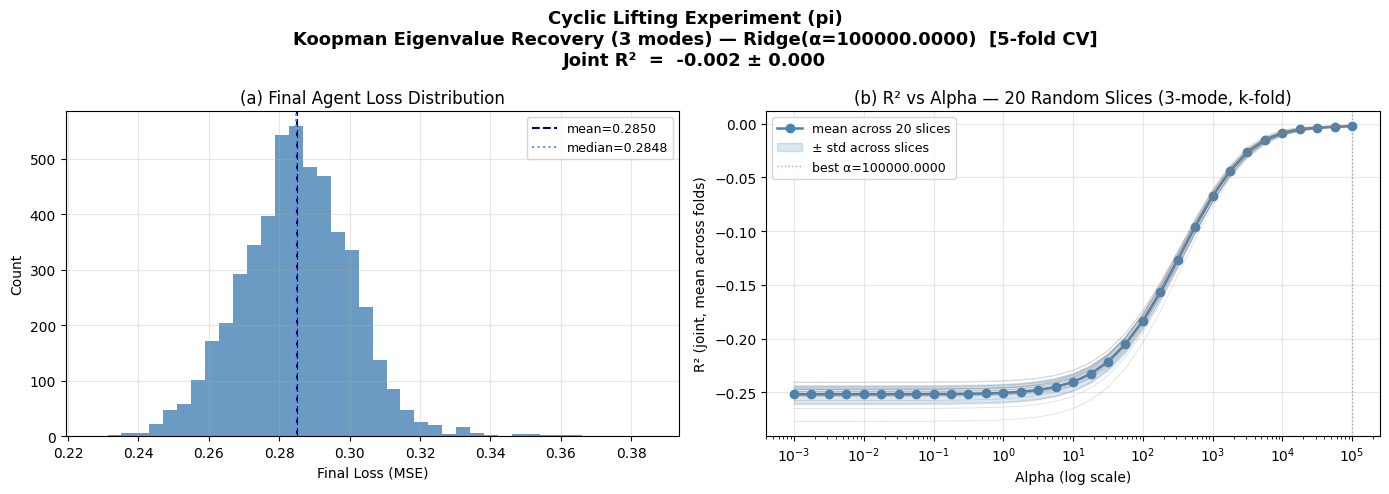

Figure 1 saved to tim_x_results_pi_M_10_n_5000_inits_1_s_32_h_32_t_200_nep_100.png


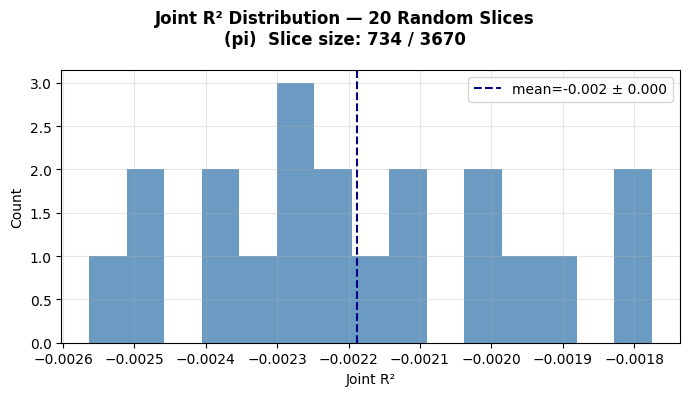

Figure 2 saved to tim_x_dist_pi_M_10_n_5000_inits_1_s_32_h_32_t_200_nep_100.png

Localization summary:
  Mean Joint R² : -0.002 ± 0.000
  Min / Max     : -0.003 / -0.002


In [12]:
# ============================================================
# Cell 13 (TIM X) | Visualization — Random Slice Probe Results
# Two figures:
#   Fig 1: Loss histogram + mean alpha curve across P slices
#   Fig 2: Distribution of Joint R² values across P slices
# ============================================================

best_idx      = int(np.argmax(probe_mean_r2_curve))
best_alpha    = probe_ridge_alphas[best_idx]
joint_r2_mean = probe_mean_r2_curve[best_idx]
joint_r2_std  = probe_std_r2_curve[best_idx]


# ── Figure 1: loss histogram + mean alpha curve ──────────────
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(
    f"Cyclic Lifting Experiment ({SEQUENCE_SOURCE})\n"
    f"Koopman Eigenvalue Recovery ({N_PROBE_MODES} modes) — "
    f"Ridge(α={best_alpha:.4f})  [{PROBE_K_FOLDS}-fold CV]\n"
    f"Joint R²  =  {joint_r2_mean:.3f} ± {joint_r2_std:.3f}",
    fontsize=13, fontweight="bold",
)

# (a) Loss histogram
ax0 = axes[0]
ax0.hist(agent_losses.flatten(), bins=40, color="steelblue",
         edgecolor="none", alpha=0.8)
ax0.axvline(np.mean(agent_losses), color="navy",
            linewidth=1.5, linestyle="--",
            label=f"mean={np.mean(agent_losses):.4f}")
ax0.axvline(np.median(agent_losses), color="cornflowerblue",
            linewidth=1.5, linestyle=":",
            label=f"median={np.median(agent_losses):.4f}")
ax0.set_title("(a) Final Agent Loss Distribution", fontsize=12)
ax0.set_xlabel("Final Loss (MSE)")
ax0.set_ylabel("Count")
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3)

# (b) Mean alpha curve across slices
ax1 = axes[1]
ax1.semilogx(probe_ridge_alphas, probe_mean_r2_curve,
             color="steelblue", linewidth=1.8, marker="o",
             label=f"mean across {N_RANDOM_SLICES} slices")
ax1.fill_between(probe_ridge_alphas,
                 probe_mean_r2_curve - probe_std_r2_curve,
                 probe_mean_r2_curve + probe_std_r2_curve,
                 color="steelblue", alpha=0.2, label="± std across slices")
for p in range(N_RANDOM_SLICES):
    ax1.semilogx(probe_ridge_alphas, random_all_mean_r2_curves[p],
                 color="grey", linewidth=0.5, alpha=0.3)
ax1.axvline(best_alpha, color="steelblue", linewidth=1.0,
            linestyle=":", alpha=0.6, label=f"best α={best_alpha:.4f}")
ax1.set_title(f"(b) R² vs Alpha — {N_RANDOM_SLICES} Random Slices "
              f"({N_PROBE_MODES}-mode, k-fold)", fontsize=12)
ax1.set_xlabel("Alpha (log scale)")
ax1.set_ylabel("R² (joint, mean across folds)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1_name = f"tim_x_results_{SAVE_DIR.split('/')[-1]}.png"
fig1.savefig(fig1_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 1 saved to {fig1_name}")


# ── Figure 2: distribution of Joint R² values ────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.suptitle(
    f"Joint R² Distribution — {N_RANDOM_SLICES} Random Slices\n"
    f"({SEQUENCE_SOURCE})  Slice size: {SLICE_SIZE} / {TOTAL_PARAM_DIM}",
    fontsize=12, fontweight="bold",
)
ax2.hist(random_all_joint_r2, bins=min(N_RANDOM_SLICES, 15),
         color="steelblue", edgecolor="none", alpha=0.8)
ax2.axvline(random_joint_r2_mean, color="navy", linewidth=1.5,
            linestyle="--",
            label=f"mean={random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
ax2.set_xlabel("Joint R²")
ax2.set_ylabel("Count")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()

fig2_name = f"tim_x_dist_{SAVE_DIR.split('/')[-1]}.png"
fig2.savefig(fig2_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 2 saved to {fig2_name}")

print(f"\nLocalization summary:")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")